# **SMOTE --> Synthetic Minority Over-sampling Technique**
**"بيعمل طلاب جدد شبه الطلاب القليلين عشان الموديل يتعلم منهم بشكل أفضل."** 😄

# **Liberaries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# **Generate Inbalance-Data**

In [2]:
X, y = make_classification(
    n_samples=1000,
    weights=[0.9, 0.1],
    random_state=42
)

In [5]:
print(pd.Series(y).value_counts())

0    897
1    103
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

# **Log-Model before SMOTE-Model**

In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[261   9]
 [ 18  12]]


# **SMOTE-model**

In [10]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print(pd.Series(y_train_smote).value_counts())

1    627
0    627
Name: count, dtype: int64


# **Log-Model After SMOTE-Model**

In [11]:
model.fit(X_train_smote, y_train_smote)
y_pred_smote = model.predict(X_test)
print(confusion_matrix(y_test, y_pred_smote))

[[233  37]
 [  9  21]]


# **Count plot Before SMOTE**

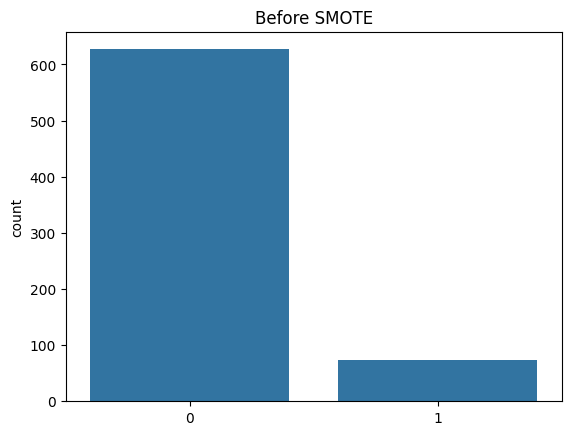

In [12]:
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

# **Count plot after SMOTE**

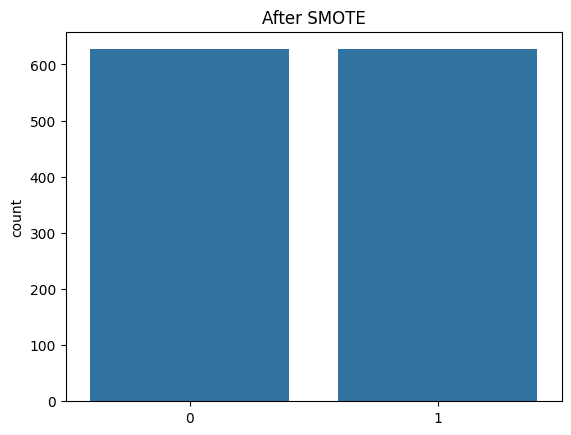

In [13]:
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")
plt.show()